# Reanalysis climatology

In [1]:
import sys
import os
import glob
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.gridspec import GridSpec
sys.path.append('/g/data/qz03/wp3/users/jb6465/code/tmd')
from utils import *

In [2]:
import warnings
import logging
warnings.filterwarnings('ignore') 
logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)
logging.getLogger('flox').setLevel(logging.WARNING)

In [3]:
import dask
import tempfile
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster

dask.config.set({
    'array.chunk-size': "256 MiB",
    'array.slicing.split_large_chunks': True, #This can make AXIOM very slow
    'distributed.comm.timeouts.connect': '120s',
    'distributed.comm.timeouts.tcp': '120s',
    'distributed.comm.retry.count': 10,
    'distributed.scheduler.allowed-failures': 20,
    "distributed.scheduler.worker-saturation": 1.1, #This should use the new behaviour which helps with memory pile up
})

# client = dask.distributed.Client()
client = Client(n_workers=10, threads_per_worker=1, local_directory = tempfile.mkdtemp(), memory_limit = "63000mb")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 10
Total threads: 10,Total memory: 586.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37321,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33077,Total threads: 1
Dashboard: /proxy/44573/status,Memory: 58.67 GiB
Nanny: tcp://127.0.0.1:44793,


## Load in reanalysis grids

In [4]:
%%time
era5_uas_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/10u/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_vas_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/10v/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_u100_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/100u/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_v100_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/100v/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_pr_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/tp/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_rsds_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/ssrd/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})


CPU times: user 5.4 s, sys: 1.31 s, total: 6.71 s
Wall time: 15.4 s


### Windspeed climatologies

In [5]:
def plot_climo(plot_type, input_climo_xr, fig_size, domain_key, plot_var, cmap, vmin, vmax, cbar_extend, cbar_label, plot_title):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    sys.path.append('/g/data/qz03/wp3/users/jb6465/code/git-repo')
    from utils import domain_dict
    
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    plot_array = input_climo_xr[plot_var]
    
    contour = plot_array.plot.imshow(ax=ax, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), cmap=cmap, add_colorbar=False) if plot_type =='raster' else plot_array.plot.contourf(ax=ax, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), cmap=cmap, levels=((vmax-vmin)*2)+1, add_colorbar=False)
    cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, fraction=0.07, shrink=0.6, extend=cbar_extend, label=cbar_label)
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(plot_title, fontsize=14, pad=12)
    ax.set_extent([domain_dict[domain_key]['lon_min'], domain_dict[domain_key]['lon_max'], domain_dict[domain_key]['lat_min'], domain_dict[domain_key]['lat_max']], crs=ccrs.PlateCarree())
    
    plt.tight_layout()
    plt.show()
    return

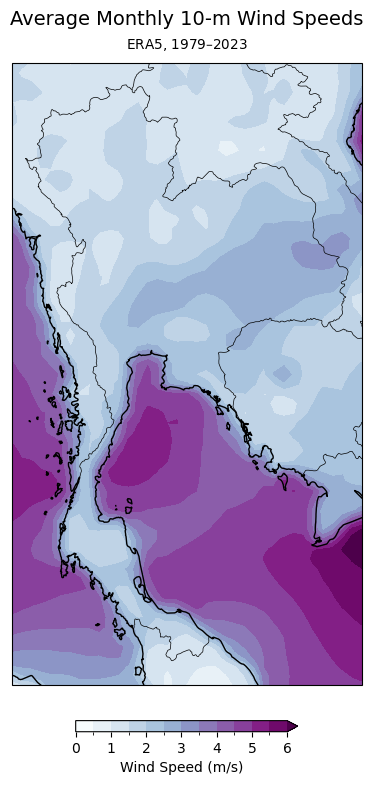

CPU times: user 16.4 s, sys: 2.38 s, total: 18.8 s
Wall time: 20.9 s


In [6]:
%%time
era5_ws10_hly = (era5_vas_hly.v10**2 + era5_uas_hly.u10**2) ** 0.5
era5_ws10_dly = (era5_ws10_hly.sortby("time")).resample(time='D').mean()
era5_ws10_dly = era5_ws10_dly.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()
plot_climo('contour', xr.Dataset({'ws10': ((era5_ws10_dly.resample(time='1M')).mean()).mean(dim='time')}), (4, 8), 'thailand', 'ws10', 'BuPu', 0, 6, 'max', 'Wind Speed (m/s)', 'Average Monthly 10-m Wind Speeds\n$_{\\text{ERA5, 1979–2023}}$')

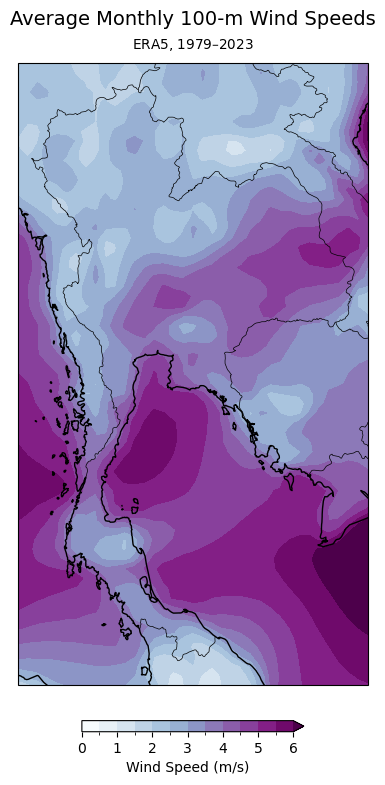

CPU times: user 15.4 s, sys: 2.19 s, total: 17.6 s
Wall time: 19.5 s


In [7]:
%%time
era5_ws100_hly = (era5_v100_hly.v100**2 + era5_u100_hly.u100**2) ** 0.5
era5_ws100_dly = (era5_ws100_hly.sortby("time")).resample(time='D').mean()
era5_ws100_dly = era5_ws100_dly.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()
plot_climo('contour', xr.Dataset({'ws100': ((era5_ws100_dly.resample(time='1M')).mean()).mean(dim='time')}), (4, 8), 'thailand', 'ws100', 'BuPu', 0, 6, 'max', 'Wind Speed (m/s)', 'Average Monthly 100-m Wind Speeds\n$_{\\text{ERA5, 1979–2023}}$')

### Multiplots

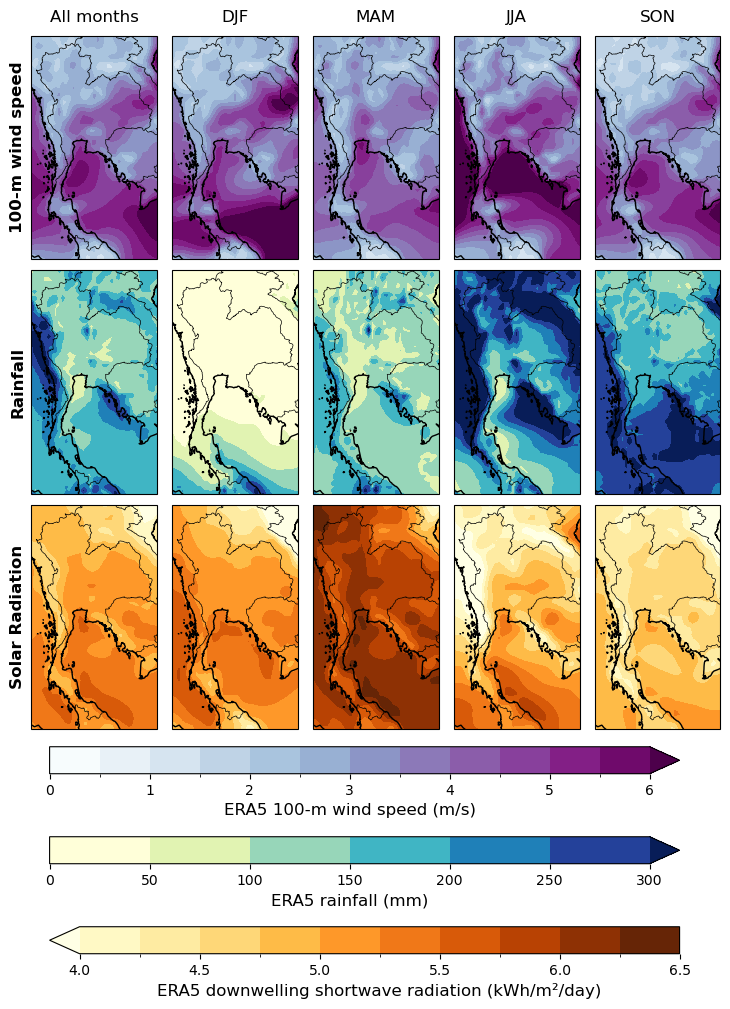

CPU times: user 1min 50s, sys: 14.5 s, total: 2min 5s
Wall time: 2min 25s


<Figure size 640x480 with 0 Axes>

In [8]:
%%time
plot_source = 'ERA5'
domain_key = 'thailand'

ws10 = xr.Dataset({'ws10': (((era5_vas_hly.v10**2 + era5_uas_hly.u10**2) ** 0.5).sortby("time").resample(time='1M')).mean()})
ws100 = xr.Dataset({'ws100': (((era5_v100_hly.v100**2 + era5_u100_hly.u100**2) ** 0.5).sortby("time").resample(time='1M')).mean()})
pr = xr.Dataset({'pr': (era5_pr_hly.tp.sortby("time")*1000).resample(time='1M').sum()}) 
ghi = xr.Dataset({'ghi': (era5_rsds_hly.ssrd.sortby("time")/(3.6e6)).resample(time='D').sum()}) #GHI units = kWh/m2 #ERA5 units = J/m2

climo_dict = {}
climo_dict['All_months-100-m_winds'] = ws100.mean(dim='time')
climo_dict['DJF_months-100-m_winds'] = ws100.sel(time=ws100.time.dt.month.isin([12, 1, 2])).mean('time')
climo_dict['MAM_months-100-m_winds'] = ws100.sel(time=ws100.time.dt.month.isin([3, 4, 5])).mean('time')
climo_dict['JJA_months-100-m_winds'] = ws100.sel(time=ws100.time.dt.month.isin([6, 7, 8])).mean('time')
climo_dict['SON_months-100-m_winds'] = ws100.sel(time=ws100.time.dt.month.isin([9, 10, 11])).mean('time')

climo_dict['All_months_months-rainfall'] = pr.mean(dim='time')
climo_dict['DJF_months-rainfall'] = pr.sel(time=pr.time.dt.month.isin([12, 1, 2])).mean('time')
climo_dict['MAM_months-rainfall'] = pr.sel(time=pr.time.dt.month.isin([3, 4, 5])).mean('time')
climo_dict['JJA_months-rainfall'] = pr.sel(time=pr.time.dt.month.isin([6, 7, 8])).mean('time')
climo_dict['SON_months-rainfall'] = pr.sel(time=pr.time.dt.month.isin([9, 10, 11])).mean('time')

climo_dict['All_months-surface_downwelling_radiation'] = ghi.mean(dim='time')
climo_dict['DJF_months-surface_downwelling_radiation'] = ghi.sel(time=ghi.time.dt.month.isin([12, 1, 2])).mean('time')
climo_dict['MAM_months-surface_downwelling_radiation'] = ghi.sel(time=ghi.time.dt.month.isin([3, 4, 5])).mean('time')
climo_dict['JJA_months-surface_downwelling_radiation'] = ghi.sel(time=ghi.time.dt.month.isin([6, 7, 8])).mean('time')
climo_dict['SON_months-surface_downwelling_radiation'] = ghi.sel(time=ghi.time.dt.month.isin([9, 10, 11])).mean('time')

fig = plt.figure(figsize=(9, 9))
gs = GridSpec(3, 5, figure=fig, hspace=0.05, wspace=0.05)
axes = [fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree()) for i in range(3) for j in range(5)]

season_order = ['All_months', 'DJF_months', 'MAM_months', 'JJA_months', 'SON_months']
var_order = ['100-m_winds', 'rainfall', 'surface_downwelling_radiation']
ordered_keys = []
for var in var_order:
    for season in season_order:
        for key in climo_dict.keys():
            if season in key and var in key:
                ordered_keys.append(key)

for ax, key in zip(axes, ordered_keys):
    plot_data = climo_dict[key]

    if '100-m_winds' in key:
        wind100m = plot_data.ws100.plot.contourf(ax=ax, vmin=0, vmax=6, levels=13, transform=ccrs.PlateCarree(), cmap='BuPu', add_colorbar=False)    
    elif 'rainfall' in key:
        rain = plot_data.pr.plot.contourf(ax=ax, vmin=0, vmax=300, levels=7, transform=ccrs.PlateCarree(), cmap='YlGnBu', add_colorbar=False)    
    elif 'radiation' in key:
        rsds = plot_data.ghi.plot.contourf(ax=ax, vmin=4, vmax=6.5, levels=11, transform=ccrs.PlateCarree(), cmap='YlOrBr', add_colorbar=False)    

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([domain_dict[domain_key]['lon_min'], domain_dict[domain_key]['lon_max'],
                   domain_dict[domain_key]['lat_min'], domain_dict[domain_key]['lat_max']], crs=ccrs.PlateCarree())
    ax.set_title('')

col_labels = ['All months', 'DJF', 'MAM', 'JJA', 'SON']
for j in range(5):
    axes[j].set_title(col_labels[j], fontsize=12, pad=10)


row_labels = ['100-m wind speed', 'Rainfall', 'Solar Radiation'] 
for i in range(3):
    ax = axes[i*5]
    ax.text(-0.05, 0.5, row_labels[i], va='center', ha='right', rotation=90,
            fontsize=12, fontweight='bold', transform=ax.transAxes)

cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.03])  
cbar = fig.colorbar(wind100m, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f"{plot_source} 100-m wind speed (m/s)", fontsize=12)

cbar_ax = fig.add_axes([0.15, -0.04, 0.7, 0.03])  
cbar = fig.colorbar(rain, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f"{plot_source} rainfall (mm)", fontsize=12)

cbar_ax = fig.add_axes([0.15, -0.14, 0.7, 0.03])   
cbar = fig.colorbar(rsds, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f"{plot_source} downwelling shortwave radiation (kWh/m²/day)", fontsize=12)

plt.show()
plt.clf()

### Timeseries plots

In [10]:
#from TMD
#solar_central_region	14.168229	100.553357
#solar_north_region	    15.368733	100.298725
#solar_northeast_region	16.75106275	102.6180582
#wind_northeast_region	15.606682	101.548846
#wind_south_region	    7.995049	100.317851

In [13]:
loc_data = (era5_ws10_dly).sel(lat=7.995049, lon=100.317851, method='nearest').sortby('time').compute() 


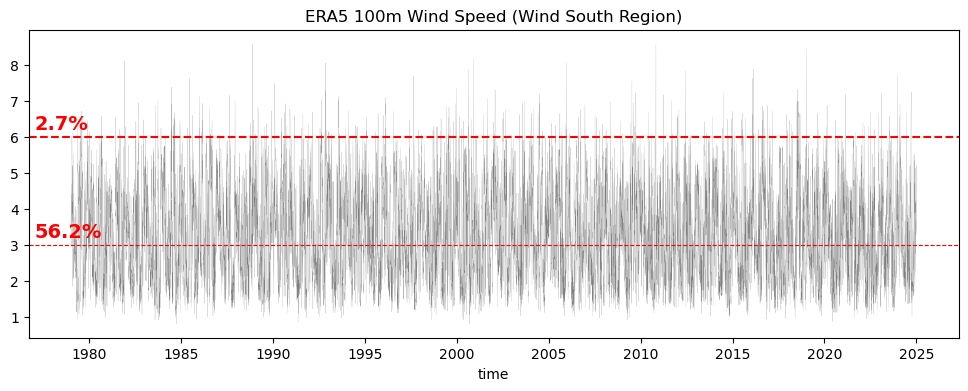

In [14]:
ax = loc_data.plot.line(color='grey', figsize=(12, 4), linewidth=0.1)
plt.title('ERA5 100m Wind Speed (Wind South Region)')

time_above_3 = 100*((loc_data > 3).sum().item())/(loc_data.shape[0])
time_above_6 = 100*((loc_data > 6).sum().item())/(loc_data.shape[0])

plt.text(np.datetime64('1977-01-01'), 3.1, f"{time_above_3:.1f}%", color='red', fontweight='bold', fontsize=14, va='bottom')
plt.text(np.datetime64('1977-01-01'), 6.1, f"{time_above_6:.1f}%", color='red', fontweight='bold', fontsize=14, va='bottom')

plt.axhline(y=3, color='red', linestyle='--', linewidth=0.8)
plt.axhline(y=6, color='red', linestyle='--')
plt.show()